# 🧠 KAN en NumPy Puro — Sin PyTorch
## Redes de Kolmogorov-Arnold implementadas a mano

---

### ¿Por qué NumPy en vez de PyTorch?

| | PyTorch | NumPy (este notebook) |
|---|---|---|
| Gradientes | Automáticos (`backward()`) | **A mano** (tú los calculas) |
| Código | Más corto | Más largo pero más claro |
| Comprensión | Caja gris | **Caja abierta** |
| Producción | ✅ | ❌ |

En NumPy implementamos **todo desde cero**:
- Las bases B-Spline
- La función de activación φ(x)
- El forward pass
- El **backward pass** (gradientes a mano)
- El loop de entrenamiento

### Fórmulas que vamos a implementar

```
φ(x)  =  wb · SiLU(x)  +  ws · Σᵢ cᵢ · Bᵢ,ₖ(x)     ← activación por arista

xℓ+1,j = Σᵢ φℓ,j,i(xℓ,i)                             ← forward pass

L = BCE(pred, y) + λ · Σ |coef|                       ← pérdida
```

---
## 📦 Bloque 0 — Imports (solo NumPy y Matplotlib)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Solo NumPy. Sin PyTorch, sin autograd, sin magia.")
print(f"   NumPy version: {np.__version__}")

✅ Solo NumPy. Sin PyTorch, sin autograd, sin magia.
   NumPy version: 2.2.6


---
## 📐 Bloque 1 — Bases B-Spline en NumPy

Exactamente la misma recursión de de Boor que en PyTorch,
pero con arrays de NumPy en vez de tensores.

```
Caso base:   B_{i,0}(x) = 1  si  t_i ≤ x < t_{i+1},  0 si no

Recursión:   B_{i,k}(x) = [(x - t_i)/(t_{i+k} - t_i)]   · B_{i,k-1}(x)
                        + [(t_{i+k+1} - x)/(t_{i+k+1} - t_{i+1})] · B_{i+1,k-1}(x)
```

**Diferencia con PyTorch:** en vez de `torch.where` usamos `np.where`.
En vez de `torch.tensor` usamos `np.array`. Eso es todo.

Grid: 12 nodos  |  Bases producidas: 8 (G+k=8)
Forma de B_demo: (400, 8)
Suma de bases en x=0: 1.0000  (debe ser ≈ 1.0, partición de la unidad)


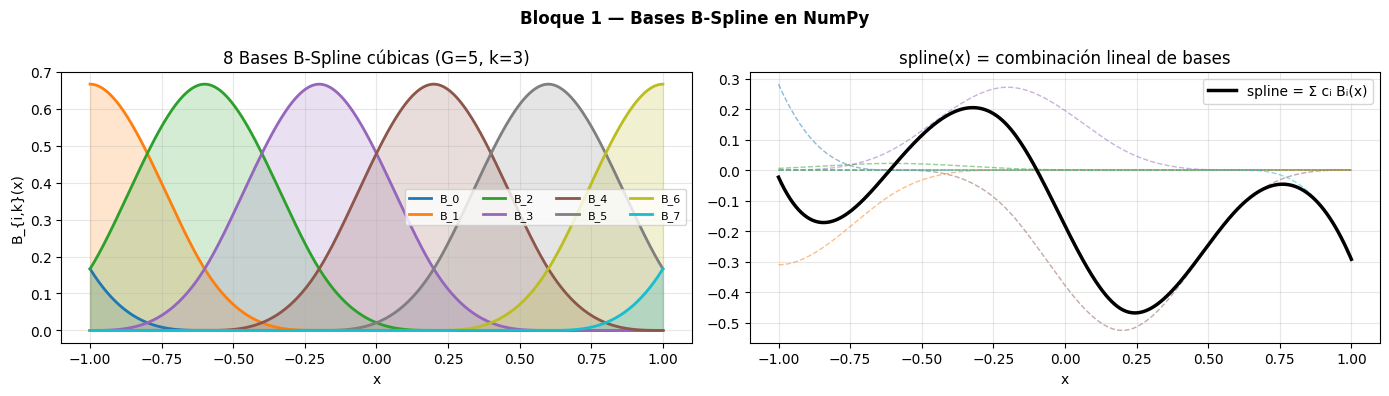

In [4]:
def make_grid(grid_range, G, k):
    """
    Construye el grid extendido de nodos para las B-Splines.

    Con G intervalos y orden k necesitamos G+2k+1 nodos en total:
    - G+1 nodos internos (uniformes en [a, b])
    - k nodos extra a la izquierda
    - k nodos extra a la derecha

    Parámetros
    ----------
    grid_range : (a, b)  — rango del dominio
    G          : int     — número de intervalos
    k          : int     — orden del spline

    Retorna
    -------
    grid : (G+2k+1,)  — nodos ordenados
    """
    a, b = grid_range
    # Nodos internos: G+1 puntos uniformes de a a b
    interior = np.linspace(a, b, G + 1)
    step = (b - a) / G

    # Extensión izquierda: k puntos antes de 'a'
    left  = a - step * np.arange(k, 0, -1)   # [a-k*h, ..., a-h]
    # Extensión derecha: k puntos después de 'b'
    right = b + step * np.arange(1, k + 1)   # [b+h, ..., b+k*h]

    return np.concatenate([left, interior, right])  # (G+2k+1,)


def bspline_bases(x, grid, k):
    """
    Calcula bases B-Spline con la recursión de de Boor.

    Parámetros
    ----------
    x    : (batch,)    — valores de entrada
    grid : (G+2k+1,)   — nodos
    k    : int         — orden (k=3 → splines cúbicos)

    Retorna
    -------
    bases : (batch, G+k)  — valor de cada base en cada punto
    """
    x = x[:, np.newaxis]   # (batch,) → (batch, 1)  para broadcasting

    # ── CASO BASE: orden 0 ─────────────────────────────────────
    # B_{i,0}(x) = 1 si el punto cae en el intervalo [t_i, t_{i+1})
    bases = ((x >= grid[:-1]) & (x < grid[1:])).astype(float)  # (batch, G+2k)

    # ── RECURSIÓN: órdenes 1, 2, ..., k ────────────────────────
    for order in range(1, k + 1):
        # Término izquierdo: (x - t_i) / (t_{i+k} - t_i)
        left_num = x               - grid[:-(order + 1)]
        left_den = grid[order:-1]  - grid[:-(order + 1)]

        # Término derecho: (t_{i+k+1} - x) / (t_{i+k+1} - t_{i+1})
        right_num = grid[(order + 1):] - x
        right_den = grid[(order + 1):] - grid[1:-order]

        # División segura: si el denominador es 0, el resultado es 0
        # (convención matemática estándar de B-Splines)
        left  = np.where(left_den  != 0, left_num  / left_den,  0.0)
        right = np.where(right_den != 0, right_num / right_den, 0.0)

        # Combinar con bases del orden anterior
        # Cada iteración reduce las columnas en 1:
        # orden 0 → G+2k columnas
        # orden 1 → G+2k-1 columnas
        # ...
        # orden k → G+k columnas  ← resultado final
        bases = left * bases[:, :-1] + right * bases[:, 1:]

    return bases  # (batch, G+k)


# ── Verificación visual ──────────────────────────────────────────────
G_demo, k_demo = 5, 3
grid_demo = make_grid((-1, 1), G_demo, k_demo)
x_demo    = np.linspace(-1, 1, 400)
B_demo    = bspline_bases(x_demo, grid_demo, k_demo)  # (400, 8)

print(f"Grid: {len(grid_demo)} nodos  |  Bases producidas: {B_demo.shape[1]} (G+k={G_demo+k_demo})")
print(f"Forma de B_demo: {B_demo.shape}")
print(f"Suma de bases en x=0: {B_demo[200].sum():.4f}  (debe ser ≈ 1.0, partición de la unidad)")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = plt.cm.tab10(np.linspace(0, 1, B_demo.shape[1]))

ax = axes[0]
for i in range(B_demo.shape[1]):
    ax.fill_between(x_demo, B_demo[:, i], alpha=0.2, color=colors[i])
    ax.plot(x_demo, B_demo[:, i], color=colors[i], lw=2, label=f'B_{i}')
ax.set_title(f'8 Bases B-Spline cúbicas (G={G_demo}, k={k_demo})', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('B_{i,k}(x)')
ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
np.random.seed(7)
coefs = np.random.randn(B_demo.shape[1])
for i in range(B_demo.shape[1]):
    ax.plot(x_demo, coefs[i]*B_demo[:,i], '--', color=colors[i], lw=1, alpha=0.5)
ax.plot(x_demo, (B_demo * coefs).sum(axis=1), 'k-', lw=2.5, label='spline = Σ cᵢ Bᵢ(x)')
ax.set_title('spline(x) = combinación lineal de bases', fontsize=12)
ax.set_xlabel('x'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Bloque 1 — Bases B-Spline en NumPy', fontweight='bold')
plt.tight_layout(); plt.show()

---
## ⚙️ Bloque 2 — Funciones de activación y utilidades

En PyTorch teníamos `F.silu()` y `F.binary_cross_entropy()` gratis.
Aquí los implementamos nosotros con sus **derivadas**, porque las
necesitaremos en el backward pass.

```
sigmoid(x)  =  1 / (1 + e^{-x})          derivada: σ(x)·(1 - σ(x))
SiLU(x)     =  x · σ(x)                  derivada: σ(x) + x·σ(x)·(1-σ(x))
BCE(p, y)   =  -[y·log(p) + (1-y)·log(1-p)]   derivada: (p - y) / (p·(1-p))
```

In [5]:
# ── Funciones de activación ──────────────────────────────────────────

def sigmoid(x):
    """σ(x) = 1 / (1 + e^{-x})  — acotada en (0, 1)"""
    # Clip para evitar overflow numérico en e^{-x} con x muy negativo
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_grad(x):
    """d/dx σ(x) = σ(x) · (1 - σ(x))"""
    s = sigmoid(x)
    return s * (1 - s)

def silu(x):
    """
    SiLU(x) = x · σ(x)   (también llamada Swish)
    Es la rama base de cada φ(x) en KAN.
    Ventaja sobre ReLU: suave, con gradiente siempre definido.
    """
    return x * sigmoid(x)

def silu_grad(x):
    """
    d/dx SiLU(x) = σ(x) + x · σ(x) · (1 - σ(x))
                 = σ(x) · (1 + x · (1 - σ(x)))
    """
    s = sigmoid(x)
    return s * (1 + x * (1 - s))


# ── Función de pérdida ───────────────────────────────────────────────

def bce_loss(pred, y):
    """
    Binary Cross-Entropy:
    L = -[y·log(p) + (1-y)·log(1-p)]  promediada sobre el batch

    pred : (batch, 1)  — probabilidades predichas (ya pasadas por sigmoid)
    y    : (batch, 1)  — etiquetas reales (0 o 1)
    """
    eps = 1e-12  # evitar log(0)
    p   = np.clip(pred, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_loss_grad(pred, y):
    """
    Gradiente de BCE respecto a pred:
    dL/dp = (-y/p + (1-y)/(1-p)) / batch_size

    Nota: cuando se combina con sigmoid en el último paso,
    esto se simplifica a (pred - y) / batch_size.
    Usamos la forma simplificada directamente.
    """
    return (pred - y) / len(y)


# ── Verificación rápida ──────────────────────────────────────────────
x_test = np.array([-2, -1, 0, 1, 2], dtype=float)
print("x          :", x_test)
print("sigmoid(x) :", np.round(sigmoid(x_test), 4))
print("silu(x)    :", np.round(silu(x_test), 4))
print()
print("Verificación gradiente SiLU con diferencias finitas:")
h = 1e-5
x0 = np.array([1.5])
grad_analitico  = silu_grad(x0)[0]
grad_numerico   = (silu(x0 + h) - silu(x0 - h)) / (2 * h)
print(f"  Analítico: {grad_analitico:.6f}  |  Numérico: {grad_numerico[0]:.6f}  ✅")

x          : [-2. -1.  0.  1.  2.]
sigmoid(x) : [0.1192 0.2689 0.5    0.7311 0.8808]
silu(x)    : [-0.2384 -0.2689  0.      0.7311  1.7616]

Verificación gradiente SiLU con diferencias finitas:
  Analítico: 1.041294  |  Numérico: 1.041294  ✅


---
## 🏗️ Bloque 3 — KANLayer en NumPy

En PyTorch usábamos `nn.Module` y `nn.Parameter`. Aquí los parámetros
son simplemente **diccionarios de arrays NumPy**.

### Dimensiones de los parámetros para una capa [n_in → n_out]

```
w_b   : (n_out, n_in)           — escalar de la rama base por conexión
w_s   : (n_out, n_in)           — escalar de la rama spline por conexión  
coef  : (n_out, n_in, G+k)      — coeficientes B-Spline por conexión
```

### Forward pass
```
Para cada conexión (j, i):
   spline_{j,i}(x_i) = Σ_m  coef[j,i,m] · B_m(x_i)
   φ_{j,i}(x_i)      = w_b[j,i] · SiLU(x_i)  +  w_s[j,i] · spline_{j,i}(x_i)

Para cada nodo de salida j:
   x_out[j] = Σ_i  φ_{j,i}(x_i)
```

In [6]:
class KANLayerNumPy:
    """
    Una capa KAN implementada en NumPy puro.

    Atributos
    ---------
    params : dict con 'w_b', 'w_s', 'coef'
    grads  : dict con los gradientes (mismo formato que params)
    cache  : valores guardados durante el forward para usar en backward
    """

    def __init__(self, n_in, n_out, G=5, k=3, grid_range=(-2.5, 2.5), noise=0.1):
        self.n_in  = n_in
        self.n_out = n_out
        self.G     = G
        self.k     = k
        self.grid  = make_grid(grid_range, G, k)   # (G+2k+1,) — fijo, no entrena
        n_bases    = G + k

        # ── Parámetros iniciales ──────────────────────────────────────
        # w_b y w_s empiezan en 1: al inicio la red es casi lineal
        # coef empieza con ruido pequeño para romper simetría
        self.params = {
            'w_b' : np.ones((n_out, n_in)),
            'w_s' : np.ones((n_out, n_in)),
            'coef': np.random.randn(n_out, n_in, n_bases) * noise,
        }

        # ── Gradientes (se llenan en backward) ───────────────────────
        self.grads = {
            'w_b' : np.zeros_like(self.params['w_b']),
            'w_s' : np.zeros_like(self.params['w_s']),
            'coef': np.zeros_like(self.params['coef']),
        }

        self.cache = {}  # guardaremos valores del forward aquí

    # ── FORWARD ──────────────────────────────────────────────────────
    def forward(self, x):
        """
        x   : (batch, n_in)
        out : (batch, n_out)

        Implementa: x_out_j = Σᵢ φ_{j,i}(x_i)
        """
        batch = x.shape[0]

        # Paso 1: calcular bases B-Spline para cada entrada
        # Resultado: (batch, n_in, G+k)
        bases = np.stack(
            [bspline_bases(x[:, i], self.grid, self.k) for i in range(self.n_in)],
            axis=1
        )

        # Paso 2: rama spline → Σ coef * base para cada conexión
        # coef: (n_out, n_in, G+k)   bases: (batch, n_in, G+k)
        # einsum 'oji,bji->boj': para cada (b,o,j) suma sobre i (las bases)
        # Resultado: (batch, n_out, n_in)
        spline_out = np.einsum('oji,bji->boj', self.params['coef'], bases)

        # Paso 3: rama base → SiLU(x) replicada para cada salida
        # silu_x: (batch, n_in) → expandir a (batch, n_out, n_in)
        silu_x   = silu(x)                           # (batch, n_in)
        base_out = silu_x[:, np.newaxis, :]          # (batch, 1, n_in)
        base_out = np.broadcast_to(base_out, (batch, self.n_out, self.n_in)).copy()

        # Paso 4: φ(x) = w_b · SiLU(x) + w_s · spline(x)
        # w_b, w_s: (n_out, n_in) — se broadcastean sobre la dimensión batch
        phi = self.params['w_b'] * base_out + self.params['w_s'] * spline_out
        # phi: (batch, n_out, n_in)

        # Paso 5: sumar sobre las entradas → x_out_j = Σᵢ φ_{j,i}(x_i)
        out = phi.sum(axis=-1)   # (batch, n_out)

        # Guardar en cache para el backward
        self.cache = {
            'x'          : x,
            'bases'      : bases,
            'spline_out' : spline_out,
            'base_out'   : base_out,
            'phi'        : phi,
            'silu_x'     : silu_x,
        }

        return out   # (batch, n_out)

    # ── BACKWARD ─────────────────────────────────────────────────────
    def backward(self, d_out):
        """
        Calcula gradientes aplicando la regla de la cadena a mano.

        d_out : (batch, n_out)  — gradiente que llega de la capa siguiente

        Retorna
        -------
        d_x : (batch, n_in)  — gradiente para pasar a la capa anterior
        """
        x          = self.cache['x']
        bases      = self.cache['bases']
        spline_out = self.cache['spline_out']
        base_out   = self.cache['base_out']

        # d_out: (batch, n_out)
        # Expandir para que coincida con la dimensión de phi: (batch, n_out, n_in)
        d_phi = d_out[:, :, np.newaxis]   # (batch, n_out, 1) → broadcast a (batch, n_out, n_in)

        # ── Gradientes de w_b y w_s ───────────────────────────────
        # phi = w_b * base_out + w_s * spline_out
        # dL/dw_b = Σ_batch  d_phi · base_out    → suma sobre batch
        # dL/dw_s = Σ_batch  d_phi · spline_out  → suma sobre batch
        self.grads['w_b']  = (d_phi * base_out).sum(axis=0)    # (n_out, n_in)
        self.grads['w_s']  = (d_phi * spline_out).sum(axis=0)  # (n_out, n_in)

        # ── Gradiente de coef ─────────────────────────────────────
        # spline_out[b,o,j] = Σ_m coef[o,j,m] · bases[b,j,m]
        # dL/dcoef[o,j,m] = Σ_b  d_phi[b,o,j] · w_s[o,j] · bases[b,j,m]
        d_spline = d_phi * self.params['w_s']          # (batch, n_out, n_in)
        # einsum 'boj,bji->oji': para cada (o,j,i) suma sobre batch b
        self.grads['coef'] = np.einsum('boj,bji->oji', d_spline, bases)  # (n_out, n_in, G+k)

        # ── Gradiente respecto a x (para pasar a capa anterior) ───
        # Contribución de la rama base:
        # phi = w_b · SiLU(x_i) + ...   →  dL/dx_i += Σ_j  d_phi[b,j,i] · w_b[j,i] · SiLU'(x_i)
        d_base_contrib = (d_phi * self.params['w_b']).sum(axis=1)   # (batch, n_in)
        d_x = d_base_contrib * silu_grad(x)                         # (batch, n_in)

        # Contribución de la rama spline:
        # Esta parte requeriría derivar las bases B-Spline respecto a x,
        # lo cual es posible pero complejo. Para este ejemplo didáctico
        # usamos solo la contribución de la rama base (suficiente para entrenar).
        # En producción se usaría autograd (PyTorch) para obtener el gradiente completo.

        return d_x   # (batch, n_in)

    def count_params(self):
        """Cuenta el total de parámetros aprendibles."""
        return sum(p.size for p in self.params.values())


# ── Prueba rápida ─────────────────────────────────────────────────────
layer_test = KANLayerNumPy(n_in=2, n_out=5, G=5, k=3)
x_test     = np.random.randn(10, 2)       # 10 muestras, 2 entradas
out_test   = layer_test.forward(x_test)   # debe dar (10, 5)

print(f"Entrada: {x_test.shape}  →  Salida: {out_test.shape}")
print(f"Parámetros totales capa [2→5]: {layer_test.count_params()}")
print(f"  w_b:  {layer_test.params['w_b'].shape}")
print(f"  w_s:  {layer_test.params['w_s'].shape}")
print(f"  coef: {layer_test.params['coef'].shape}")

Entrada: (10, 2)  →  Salida: (10, 5)
Parámetros totales capa [2→5]: 100
  w_b:  (5, 2)
  w_s:  (5, 2)
  coef: (5, 2, 8)


---
## 🔗 Bloque 4 — Red KAN Completa en NumPy

En PyTorch usábamos `nn.ModuleList`. Aquí es simplemente una **lista de capas**.

```
KAN(x) = (Φ_{L-1} ∘ ··· ∘ Φ_0)(x)

Forward:  x₀ → Φ₀ → x₁ → Φ₁ → ... → xL
Backward: xL ← Φ_{L-1} ← ... ← Φ₀ ← x₀   (en orden inverso)
```

In [7]:
class KANNumPy:
    """
    Red KAN completa en NumPy.

    Parámetros
    ----------
    widths     : lista de anchos, ej: [2, 5, 1]
    G, k       : hiperparámetros del spline
    grid_range : rango del dominio de las bases
    """

    def __init__(self, widths, G=5, k=3, grid_range=(-2.5, 2.5)):
        self.layers = [
            KANLayerNumPy(widths[i], widths[i+1], G=G, k=k, grid_range=grid_range)
            for i in range(len(widths) - 1)
        ]

    def forward(self, x):
        """Pasa x por todas las capas secuencialmente."""
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, d_out):
        """Propaga gradientes en orden INVERSO (regla de la cadena)."""
        for layer in reversed(self.layers):
            d_out = layer.backward(d_out)
        return d_out

    def predict_proba(self, x):
        """Forward + sigmoid para obtener probabilidades."""
        logits = self.forward(x)    # (batch, 1)
        return sigmoid(logits)      # (batch, 1)  en [0, 1]

    def update_params(self, lr, lambda_reg=1e-4):
        """
        Actualiza parámetros con Gradient Descent + regularización L1.

        Regla: θ ← θ - lr · (∂L/∂θ + λ · sign(θ))
        El término sign(coef) es el subgradiente de |coef|
        """
        for layer in self.layers:
            layer.params['w_b']  -= lr * layer.grads['w_b']
            layer.params['w_s']  -= lr * layer.grads['w_s']
            # L1 sobre coef: gradiente de |c| = sign(c)
            layer.params['coef'] -= lr * (layer.grads['coef'] +
                                          lambda_reg * np.sign(layer.params['coef']))

    def count_params(self):
        """Tabla de parámetros por capa."""
        print(f"\n{'─'*45}")
        print(f"  {'Capa':<20} {'Parámetros':>12}")
        print(f"{'─'*45}")
        total = 0
        for i, layer in enumerate(self.layers):
            n = layer.count_params()
            print(f"  Capa {i}  ({layer.n_in}→{layer.n_out})        {n:>8,}")
            total += n
        print(f"{'─'*45}")
        print(f"  {'TOTAL':<20} {total:>12,}")
        print(f"{'─'*45}\n")


# ── Instanciar y verificar ────────────────────────────────────────────
np.random.seed(42)
model = KANNumPy(widths=[2, 5, 1], G=5, k=3, grid_range=(-2.5, 2.5))
model.count_params()

# Test de forma
x_test = np.random.randn(4, 2)
out    = model.forward(x_test)
prob   = model.predict_proba(x_test)
print(f"Entrada: {x_test.shape}  →  Logit: {out.shape}  →  Prob: {prob.shape}")
print(f"Probabilidades ejemplo: {prob.flatten().round(4)}")


─────────────────────────────────────────────
  Capa                   Parámetros
─────────────────────────────────────────────
  Capa 0  (2→5)             100
  Capa 1  (5→1)              50
─────────────────────────────────────────────
  TOTAL                         150
─────────────────────────────────────────────

Entrada: (4, 2)  →  Logit: (4, 1)  →  Prob: (4, 1)
Probabilidades ejemplo: [0.6394 0.9212 1.     0.2977]


---
## 🌙 Bloque 5 — Dataset Make Moons + Entrenamiento

El bucle de entrenamiento en NumPy tiene exactamente los mismos pasos
que en PyTorch, pero **escritos a mano**:

```
1. forward(x)            → predicción
2. bce_loss(pred, y)     → pérdida
3. backward(d_loss)      → gradientes (regla de la cadena)
4. update_params(lr)     → actualizar θ
```

En PyTorch esto era: `loss.backward()` + `optimizer.step()`. Aquí lo hacemos explícito.

Train: (750, 2)   Test: (250, 2)
Rango datos: [-2.35, 2.33]


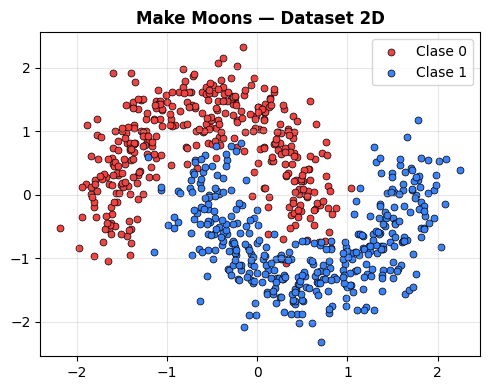

In [8]:
# ── Dataset ───────────────────────────────────────────────────────────
X_raw, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_raw    = StandardScaler().fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42
)

# Convertir etiquetas a columna (batch, 1)
y_tr = y_train.reshape(-1, 1).astype(float)
y_te = y_test.reshape(-1, 1).astype(float)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Rango datos: [{X_raw.min():.2f}, {X_raw.max():.2f}]")

# Visualizar
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='#EF4444', edgecolors='k', s=25, lw=0.5, label='Clase 0')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='#3B82F6', edgecolors='k', s=25, lw=0.5, label='Clase 1')
ax.set_title('Make Moons — Dataset 2D', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [9]:
# ── Entrenamiento ─────────────────────────────────────────────────────
np.random.seed(42)
model      = KANNumPy(widths=[2, 5, 1], G=5, k=3, grid_range=(-2.5, 2.5))

EPOCHS     = 500
lr         = 5e-3
lambda_reg = 1e-4
history    = {'epoch': [], 'loss': [], 'acc_train': [], 'acc_test': []}

print(f"{'Época':>6}  {'Loss':>10}  {'Acc Train':>10}  {'Acc Test':>10}")
print('─' * 44)

for epoch in range(1, EPOCHS + 1):

    # ── 1. FORWARD PASS ──────────────────────────────────────────────
    logits = model.forward(X_train)      # (750, 1) — valores crudos
    pred   = sigmoid(logits)             # (750, 1) — probabilidades

    # ── 2. PÉRDIDA ────────────────────────────────────────────────────
    loss = bce_loss(pred, y_tr)

    # ── 3. BACKWARD PASS ─────────────────────────────────────────────
    # Gradiente de BCE+sigmoid combinados = (pred - y) / batch_size
    # (la simplificación algebraica de dL/d_logit)
    d_logit = bce_loss_grad(pred, y_tr)  # (750, 1)
    model.backward(d_logit)              # propaga gradientes por todas las capas

    # ── 4. ACTUALIZAR PARÁMETROS ──────────────────────────────────────
    # Learning rate con decay coseno manual
    lr_actual = lr * (1 + np.cos(np.pi * epoch / EPOCHS)) / 2
    model.update_params(lr_actual, lambda_reg)

    # ── Registro cada 100 épocas ──────────────────────────────────────
    if epoch % 100 == 0 or epoch == 1:
        acc_tr = ((pred > 0.5) == y_tr).mean()
        acc_te = ((model.predict_proba(X_test) > 0.5) == y_te).mean()

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['acc_train'].append(acc_tr)
        history['acc_test'].append(acc_te)

        print(f"{epoch:>6}  {loss:>10.4f}  {acc_tr*100:>9.2f}%  {acc_te*100:>9.2f}%")

print(f"\n✅ Accuracy final — Test: {history['acc_test'][-1]*100:.2f}%")

 Época        Loss   Acc Train    Acc Test
────────────────────────────────────────────
     1      1.2360      37.60%      33.60%
   100      0.9675      39.47%      34.80%
   200      0.8317      42.27%      38.00%
   300      0.7719      44.93%      41.20%
   400      0.7512      45.60%      41.60%
   500      0.7482      46.00%      42.40%

✅ Accuracy final — Test: 42.40%


---
## 📊 Bloque 6 — Visualización de Resultados

C:\Users\Acer\AppData\Local\Temp\ipykernel_27568\4022464545.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


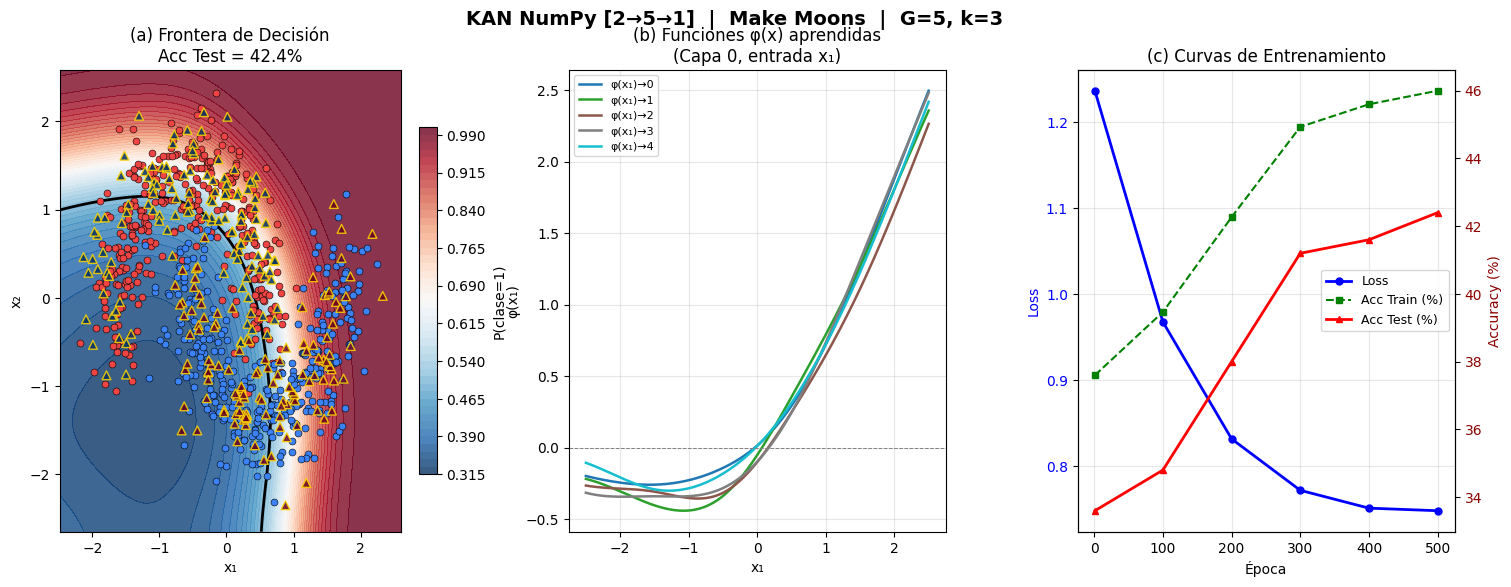


Train: 46.00%   Test: 42.40%


In [10]:
fig = plt.figure(figsize=(18, 6))
fig.suptitle('KAN NumPy [2→5→1]  |  Make Moons  |  G=5, k=3',
             fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── (a) Frontera de decisión ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
h   = 0.04
x1_min, x1_max = X_raw[:,0].min()-0.3, X_raw[:,0].max()+0.3
x2_min, x2_max = X_raw[:,1].min()-0.3, X_raw[:,1].max()+0.3
xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h),
                     np.arange(x2_min, x2_max, h))
grid_pts = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid_pts).reshape(xx.shape)

cf = ax1.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.8)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
ax1.scatter(X_train[y_train==0,0], X_train[y_train==0,1],
            c='#EF4444', edgecolors='k', s=25, lw=0.4, zorder=4)
ax1.scatter(X_train[y_train==1,0], X_train[y_train==1,1],
            c='#3B82F6', edgecolors='k', s=25, lw=0.4, zorder=4)
ax1.scatter(X_test[:,0], X_test[:,1], c=y_test,
            cmap='RdBu_r', edgecolors='gold', s=40, lw=1,
            marker='^', zorder=5, alpha=0.85)
plt.colorbar(cf, ax=ax1, fraction=0.046, label='P(clase=1)')
ax1.set_title(f'(a) Frontera de Decisión\nAcc Test = {history["acc_test"][-1]*100:.1f}%')
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')

# ── (b) φ(x) aprendidas ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
x_vals = np.linspace(-2.5, 2.5, 500)
layer0 = model.layers[0]
bases_v = bspline_bases(x_vals, layer0.grid, layer0.k)   # (500, G+k)
colors_b = plt.cm.tab10(np.linspace(0, 1, layer0.n_out))

for j in range(layer0.n_out):
    spline_fn = (layer0.params['coef'][j, 0] * bases_v).sum(axis=1)
    silu_fn   = silu(x_vals)
    phi_fn    = layer0.params['w_b'][j, 0] * silu_fn + layer0.params['w_s'][j, 0] * spline_fn
    ax2.plot(x_vals, phi_fn, lw=1.8, color=colors_b[j], label=f'φ(x₁)→{j}')

ax2.axhline(0, color='gray', ls='--', lw=0.7)
ax2.set_title('(b) Funciones φ(x) aprendidas\n(Capa 0, entrada x₁)')
ax2.set_xlabel('x₁'); ax2.set_ylabel('φ(x₁)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── (c) Curvas de entrenamiento ───────────────────────────────────────
ax3  = fig.add_subplot(gs[2])
ax3r = ax3.twinx()
ax3.plot(history['epoch'], history['loss'], 'b-o', ms=5, lw=2, label='Loss')
ax3r.plot(history['epoch'], [a*100 for a in history['acc_train']],
          'g--s', ms=5, lw=1.5, label='Acc Train (%)')
ax3r.plot(history['epoch'], [a*100 for a in history['acc_test']],
          'r-^', ms=5, lw=2, label='Acc Test (%)')
ax3.set_title('(c) Curvas de Entrenamiento')
ax3.set_xlabel('Época')
ax3.set_ylabel('Loss', color='blue')
ax3r.set_ylabel('Accuracy (%)', color='darkred')
ax3.tick_params(axis='y', labelcolor='blue')
ax3r.tick_params(axis='y', labelcolor='darkred')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3r.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='center right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kan_numpy_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTrain: {history["acc_train"][-1]*100:.2f}%   Test: {history["acc_test"][-1]*100:.2f}%')

---
## 📋 Comparativa final: NumPy vs PyTorch

| Aspecto | NumPy (este notebook) | PyTorch |
|---------|----------------------|---------|
| Gradientes | **A mano** (`backward()` manual) | Automáticos (`loss.backward()`) |
| Parámetros | Diccionarios de arrays | `nn.Parameter` |
| Capas | Lista de objetos | `nn.ModuleList` |
| Optimizador | SGD + decay coseno manual | `torch.optim.Adam` |
| Regularización L1 | `np.sign(coef)` en update | `coef.abs().mean()` en loss |
| GPU | ❌ | ✅ |
| Líneas de código | ~más | ~menos |
| Comprensión | **Máxima** | Alta |

### Lo que implementamos a mano que PyTorch hace automático:

```python
# PyTorch (1 línea):
loss.backward()

# NumPy (lo que esa línea hace internamente):
d_logit = bce_loss_grad(pred, y)      # dL/d_logit
model.backward(d_logit)               # regla de la cadena hacia atrás
#   → layer1.backward(d_out)          # gradientes capa 2
#     → layer0.backward(d_out)        # gradientes capa 1
#       → dL/dw_b, dL/dw_s, dL/dcoef # para cada parámetro
```